# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Patient Comorbidity risk Assesment Dataset](https://www.kaggle.com/datasets/velvetcrystal/patient-comorbidity-risk-assessment-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

/kaggle/input/datasets/velvetcrystal/patient-comorbidity-risk-assessment-dataset/Patient_Comorbidity_Risk_Assessment_Dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Patient_Comorbidity_Risk_Assessment_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
0,PT100001,63,Female,18.8,Former,NaN,High,0,0,0,0,170.0,120.0,80.0,89.0,4.9,0,74.0,1.1,4.5
1,PT100002,41,Male,35.1,Never,NaN,NaN,0,0,0,0,174.0,131.0,72.0,81.0,NaN,0,100.0,7.8,7.3
2,PT100003,70,Female,34.6,Never,Low,NaN,0,0,0,0,221.0,135.0,77.0,77.0,5.6,0,88.0,5.4,7.5
3,PT100004,73,Male,39.8,Never,Low,Moderate,0,1,0,0,168.0,165.0,102.0,78.0,5.6,0,93.0,19.7,25.1
4,PT100005,27,Male,33.1,Current,High,Low,0,0,0,0,147.0,NaN,70.0,88.0,6.1,0,100.0,11.6,6.3


## last Five row

In [4]:
df.tail()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
9995,PT109996,84,Male,NaN,Never,NaN,High,0,0,0,0,NaN,125.0,80.0,49.0,5.5,0,65.0,8.4,14.9
9996,PT109997,57,Male,18.1,Current,Low,Moderate,0,0,0,0,153.0,112.0,72.0,82.0,4.7,1,87.0,25.4,9.0
9997,PT109998,59,Female,15.9,Never,NaN,Low,0,0,0,0,168.0,117.0,62.0,84.0,5.1,1,72.0,10.2,0.0
9998,PT109999,76,Female,31.6,NaN,NaN,NaN,0,0,0,0,231.0,120.0,94.0,82.0,NaN,0,79.0,22.4,11.0
9999,PT110000,55,Female,23.9,Former,Moderate,Low,1,0,0,1,222.0,93.0,78.0,94.0,6.9,0,100.0,26.2,24.3


## Shape of our dataset

In [5]:
df.shape

(10000, 20)

## List out all columns

In [6]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Physical_Activity_Level', 'Diabetes',
       'Hypertension', 'Chronic_Kidney_Disease', 'Liver_Disease',
       'Cholesterol_Level', 'Systolic_BP', 'Diastolic_BP',
       'Resting_Heart_Rate', 'HbA1c', 'Family_History_CVD',
       'Medication_Adherence_Percentage', 'Heart_Attack_Risk_Percentage',
       'Mortality_Risk_Percentage'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Patient_ID                          object
Age                                  int64
Gender                              object
BMI                                float64
Smoking_Status                      object
Alcohol_Consumption                 object
Physical_Activity_Level             object
Diabetes                             int64
Hypertension                         int64
Chronic_Kidney_Disease               int64
Liver_Disease                        int64
Cholesterol_Level                  float64
Systolic_BP                        float64
Diastolic_BP                       float64
Resting_Heart_Rate                 float64
HbA1c                              float64
Family_History_CVD                   int64
Medication_Adherence_Percentage    float64
Heart_Attack_Risk_Percentage       float64
Mortality_Risk_Percentage          float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient_ID                       10000 non-null  object 
 1   Age                              10000 non-null  int64  
 2   Gender                           10000 non-null  object 
 3   BMI                              9338 non-null   float64
 4   Smoking_Status                   9385 non-null   object 
 5   Alcohol_Consumption              6066 non-null   object 
 6   Physical_Activity_Level          9262 non-null   object 
 7   Diabetes                         10000 non-null  int64  
 8   Hypertension                     10000 non-null  int64  
 9   Chronic_Kidney_Disease           10000 non-null  int64  
 10  Liver_Disease                    10000 non-null  int64  
 11  Cholesterol_Level                9423 non-null   float64
 12  Systolic_BP        

## Check Null Value

In [9]:
df.isnull().sum()

Patient_ID                            0
Age                                   0
Gender                                0
BMI                                 662
Smoking_Status                      615
Alcohol_Consumption                3934
Physical_Activity_Level             738
Diabetes                              0
Hypertension                          0
Chronic_Kidney_Disease                0
Liver_Disease                         0
Cholesterol_Level                   577
Systolic_BP                         571
Diastolic_BP                        571
Resting_Heart_Rate                  698
HbA1c                               538
Family_History_CVD                    0
Medication_Adherence_Percentage     766
Heart_Attack_Risk_Percentage          0
Mortality_Risk_Percentage             0
dtype: int64

## Fill numerical columns with median

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

## Fill categorical columns with mode

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col != 'Patient_ID':
        df[col].fillna(df[col].mode()[0], inplace=True)

## Check remaining null values

In [12]:
print(df.isnull().sum())

Patient_ID                         0
Age                                0
Gender                             0
BMI                                0
Smoking_Status                     0
Alcohol_Consumption                0
Physical_Activity_Level            0
Diabetes                           0
Hypertension                       0
Chronic_Kidney_Disease             0
Liver_Disease                      0
Cholesterol_Level                  0
Systolic_BP                        0
Diastolic_BP                       0
Resting_Heart_Rate                 0
HbA1c                              0
Family_History_CVD                 0
Medication_Adherence_Percentage    0
Heart_Attack_Risk_Percentage       0
Mortality_Risk_Percentage          0
dtype: int64


## Check Dupicate Value

In [13]:
df.duplicated().sum()

np.int64(0)

## Summary

In [14]:
df.describe()

,Age,BMI,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,57.809800,27.638270,0.08260,0.203300,0.052000,0.061100,191.861500,121.841300,76.643700,76.885100,5.567170,0.247500,79.83200,18.269930,12.031570
std,15.831307,5.269342,0.27529,0.402474,0.222038,0.239526,27.749417,15.114177,9.229413,9.899783,0.823797,0.431581,12.63616,13.775983,12.022517
min,18.000000,15.000000,0.00000,0.000000,0.000000,0.000000,100.000000,80.000000,50.000000,40.000000,4.000000,0.000000,29.00000,0.000000,0.000000
25%,47.000000,24.200000,0.00000,0.000000,0.000000,0.000000,174.000000,112.000000,71.000000,71.000000,5.200000,0.000000,72.00000,7.600000,3.000000
50%,58.000000,27.600000,0.00000,0.000000,0.000000,0.000000,192.000000,121.000000,76.000000,77.000000,5.400000,0.000000,80.00000,15.900000,8.900000
75%,68.000000,30.900000,0.00000,0.000000,0.000000,0.000000,210.000000,131.000000,82.000000,83.000000,5.700000,0.000000,89.00000,26.400000,17.300000
max,95.000000,47.800000,1.00000,1.000000,1.000000,1.000000,315.000000,188.000000,112.000000,116.000000,11.800000,1.000000,100.00000,86.400000,85.700000


# EDA

In [15]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

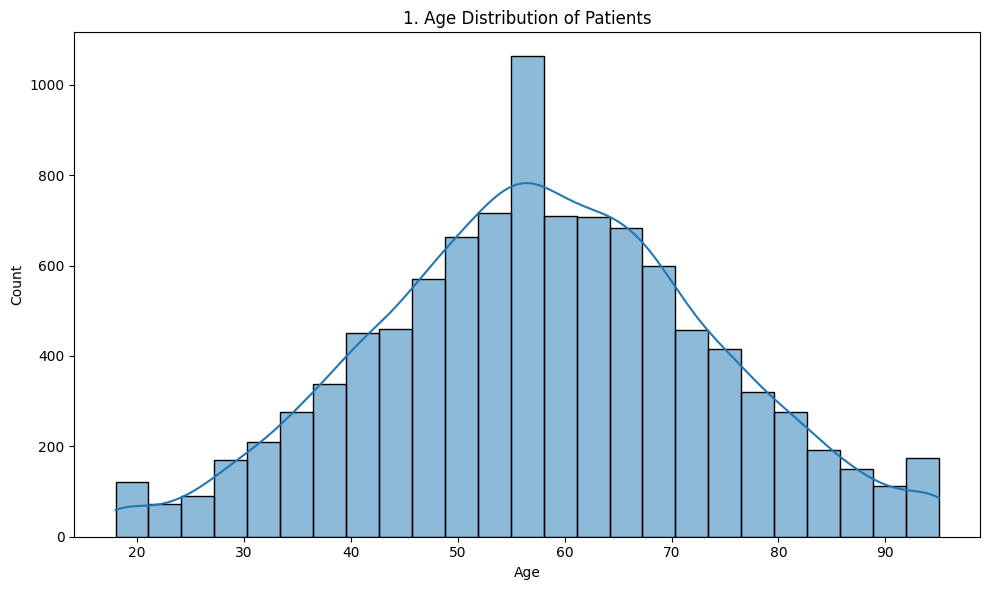

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=25, kde=True)
plt.title(f'{plot_no}. Age Distribution of Patients')
show_fig()
plot_no += 1

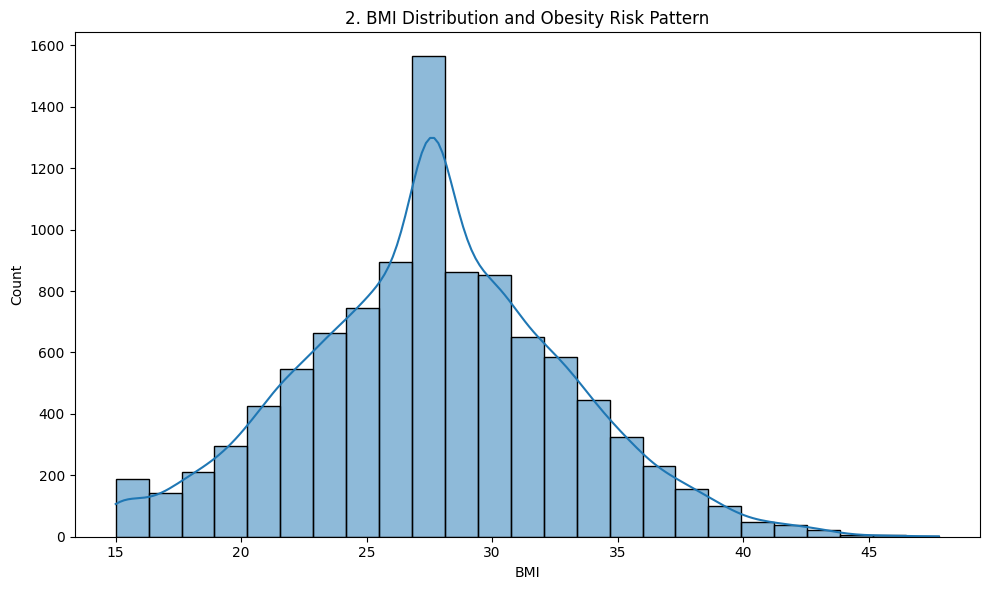

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['BMI'], bins=25, kde=True)
plt.title(f'{plot_no}. BMI Distribution and Obesity Risk Pattern')
show_fig()
plot_no += 1

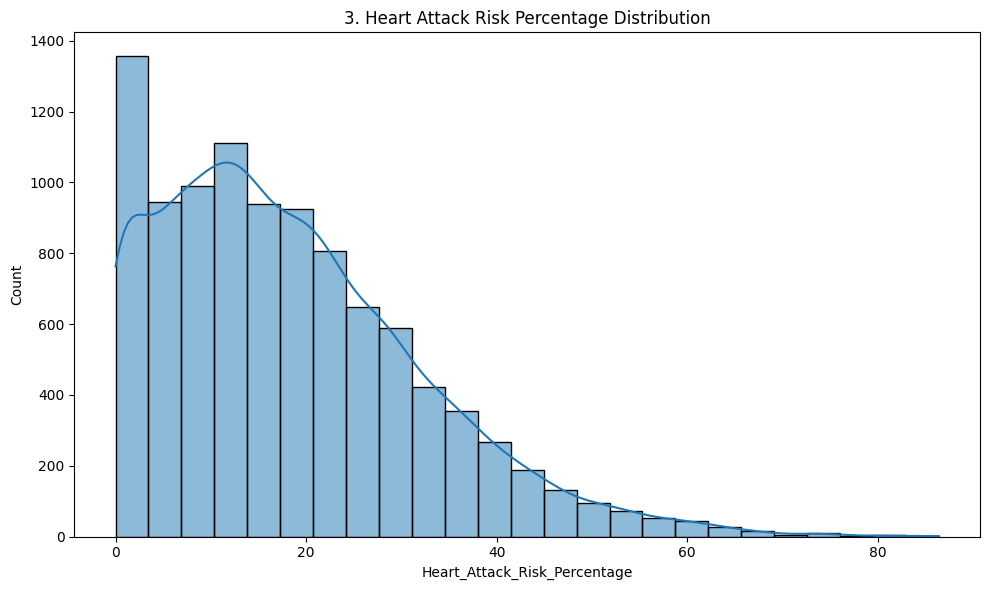

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Heart_Attack_Risk_Percentage'], bins=25, kde=True)
plt.title(f'{plot_no}. Heart Attack Risk Percentage Distribution')
show_fig()
plot_no += 1

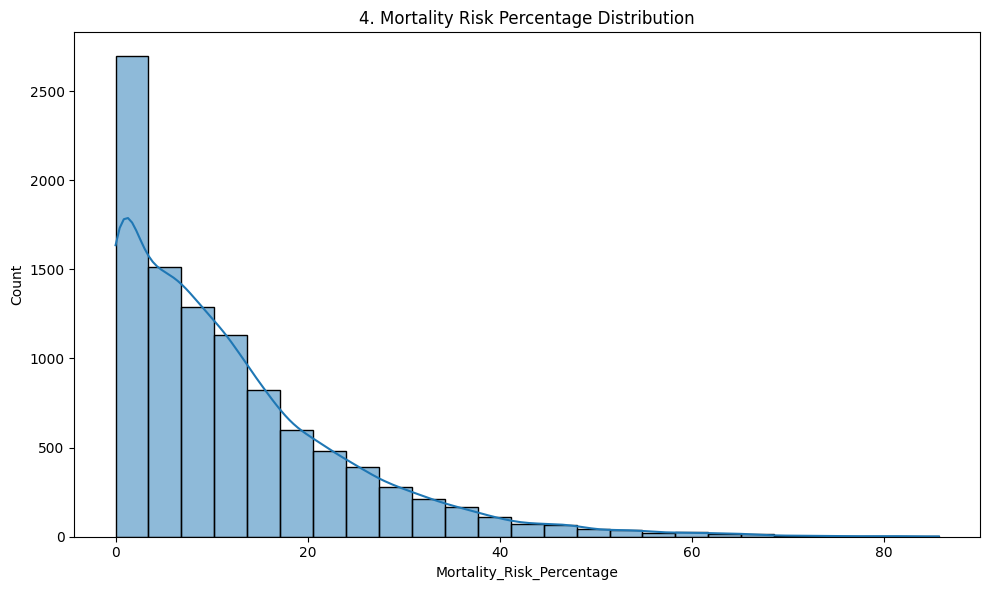

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Mortality_Risk_Percentage'], bins=25, kde=True)
plt.title(f'{plot_no}. Mortality Risk Percentage Distribution')
show_fig()
plot_no += 1

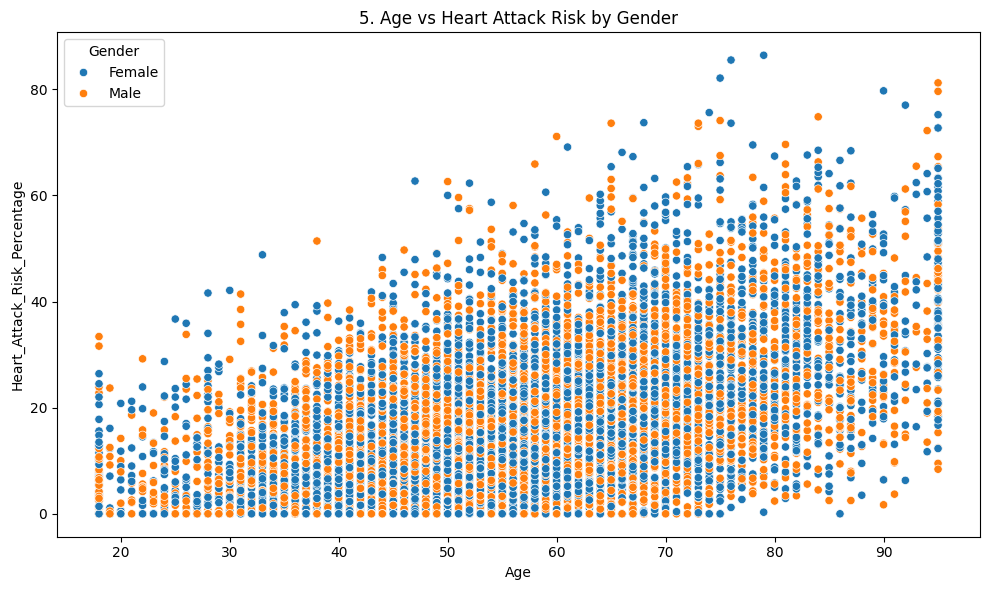

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Heart_Attack_Risk_Percentage', hue='Gender')
plt.title(f'{plot_no}. Age vs Heart Attack Risk by Gender')
show_fig()
plot_no += 1

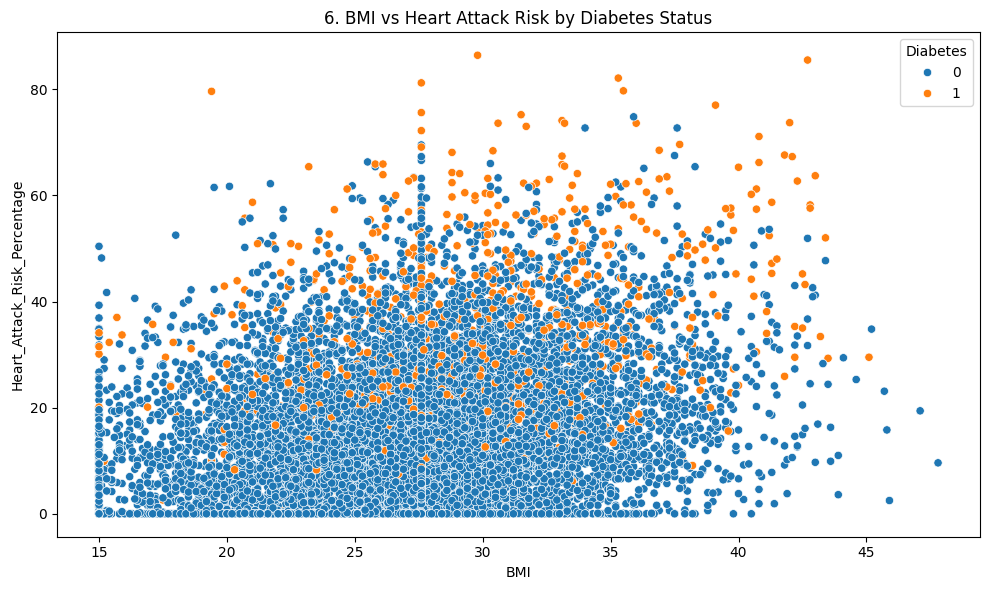

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='BMI', y='Heart_Attack_Risk_Percentage', hue='Diabetes')
plt.title(f'{plot_no}. BMI vs Heart Attack Risk by Diabetes Status')
show_fig()
plot_no += 1

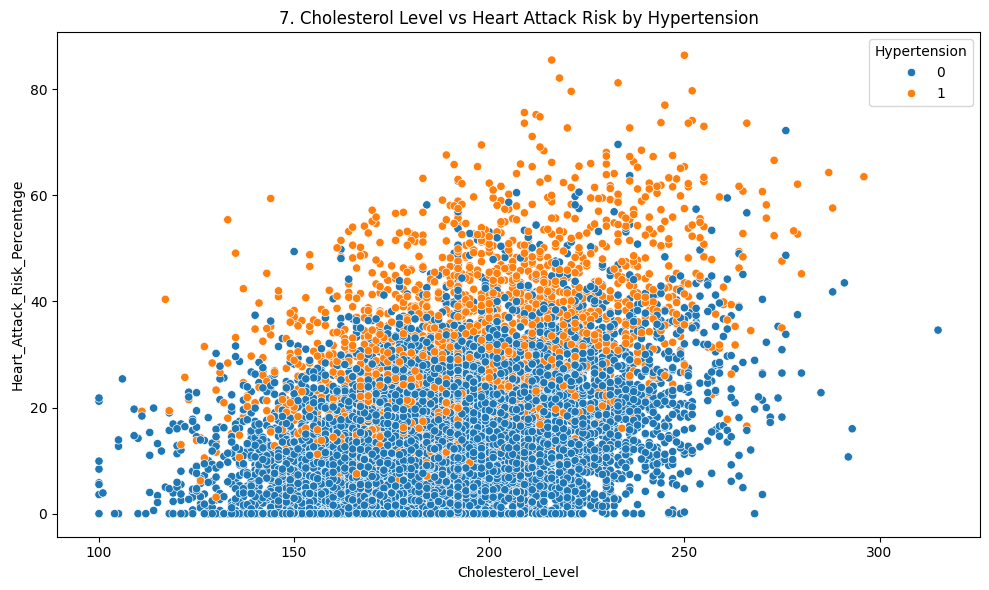

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Cholesterol_Level', y='Heart_Attack_Risk_Percentage', hue='Hypertension')
plt.title(f'{plot_no}. Cholesterol Level vs Heart Attack Risk by Hypertension')
show_fig()
plot_no += 1

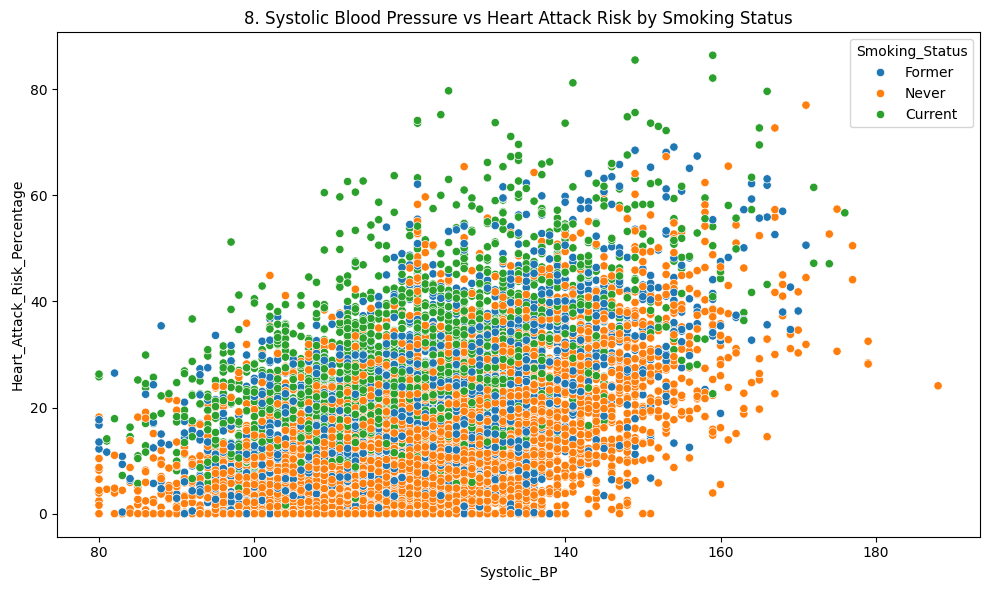

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Systolic_BP', y='Heart_Attack_Risk_Percentage', hue='Smoking_Status')
plt.title(f'{plot_no}. Systolic Blood Pressure vs Heart Attack Risk by Smoking Status')
show_fig()
plot_no += 1

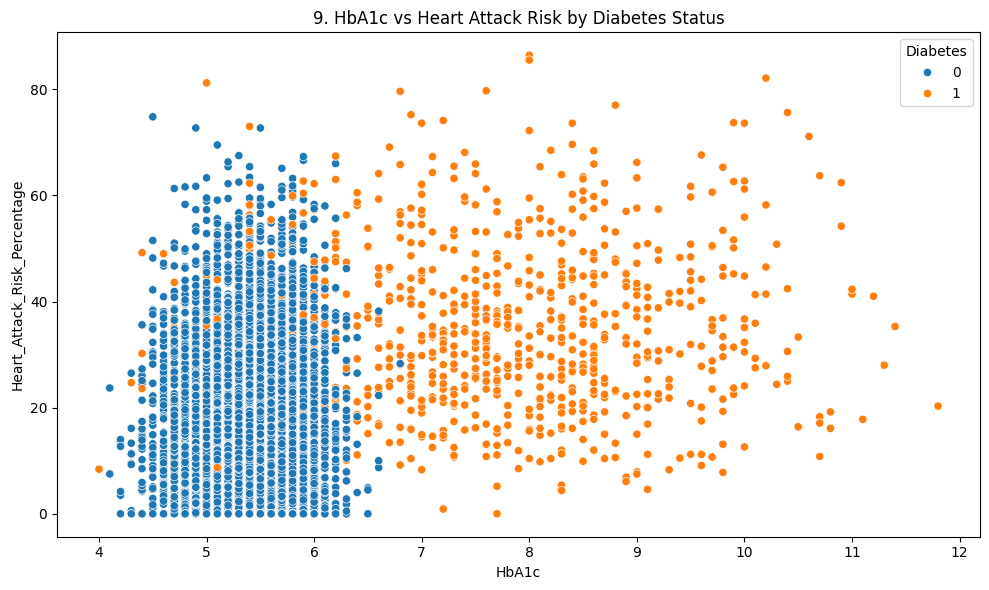

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='HbA1c', y='Heart_Attack_Risk_Percentage', hue='Diabetes')
plt.title(f'{plot_no}. HbA1c vs Heart Attack Risk by Diabetes Status')
show_fig()
plot_no += 1

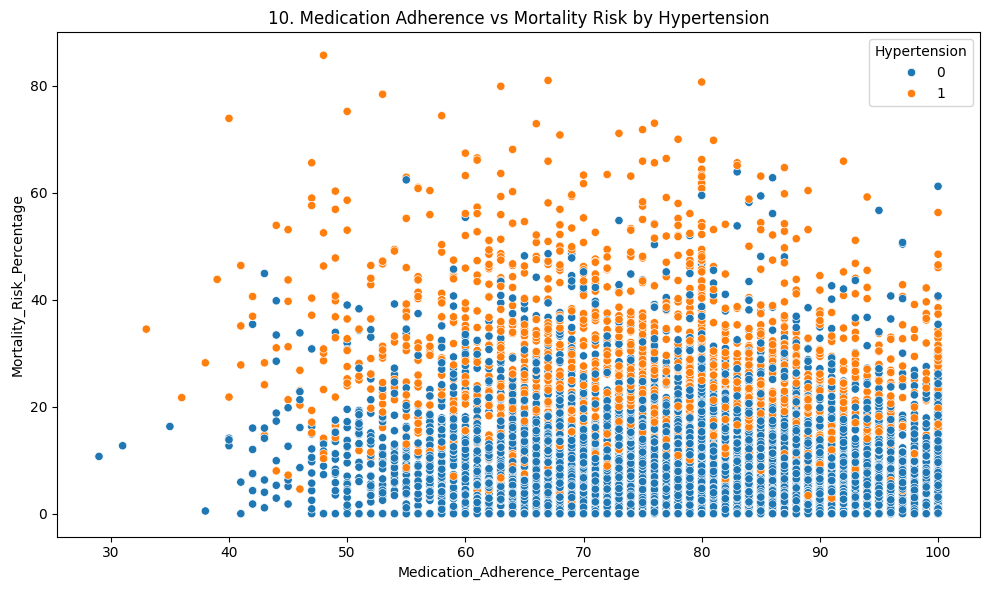

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Medication_Adherence_Percentage', y='Mortality_Risk_Percentage', hue='Hypertension')
plt.title(f'{plot_no}. Medication Adherence vs Mortality Risk by Hypertension')
show_fig()
plot_no += 1

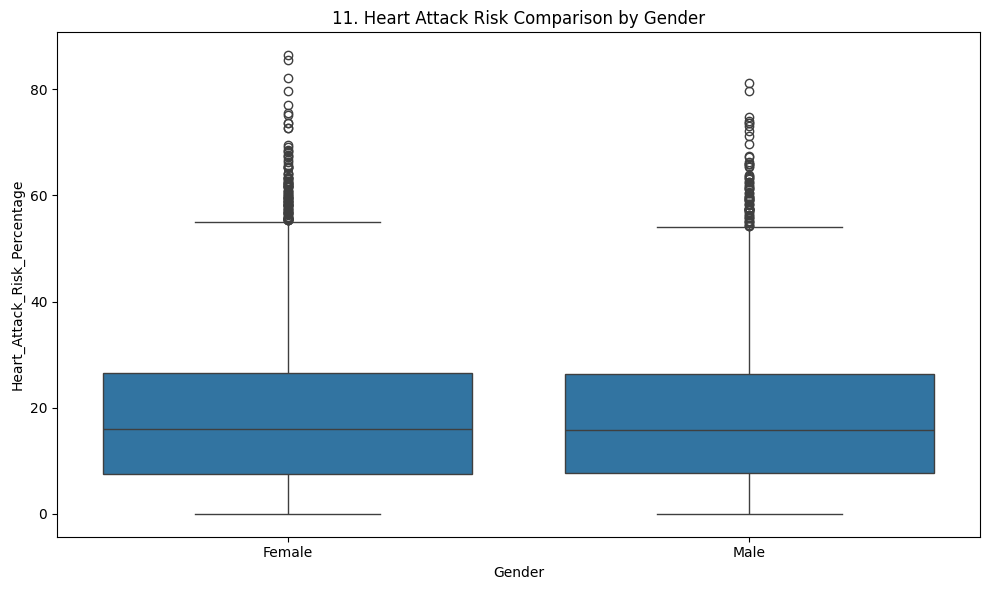

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Gender', y='Heart_Attack_Risk_Percentage')
plt.title(f'{plot_no}. Heart Attack Risk Comparison by Gender')
show_fig()
plot_no += 1

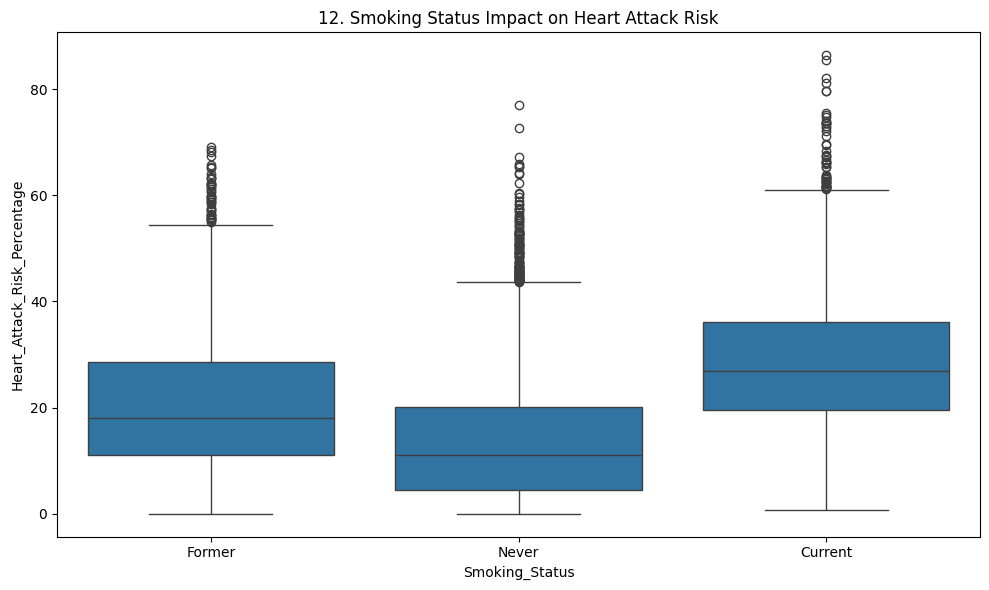

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Smoking_Status', y='Heart_Attack_Risk_Percentage')
plt.title(f'{plot_no}. Smoking Status Impact on Heart Attack Risk')
show_fig()
plot_no += 1

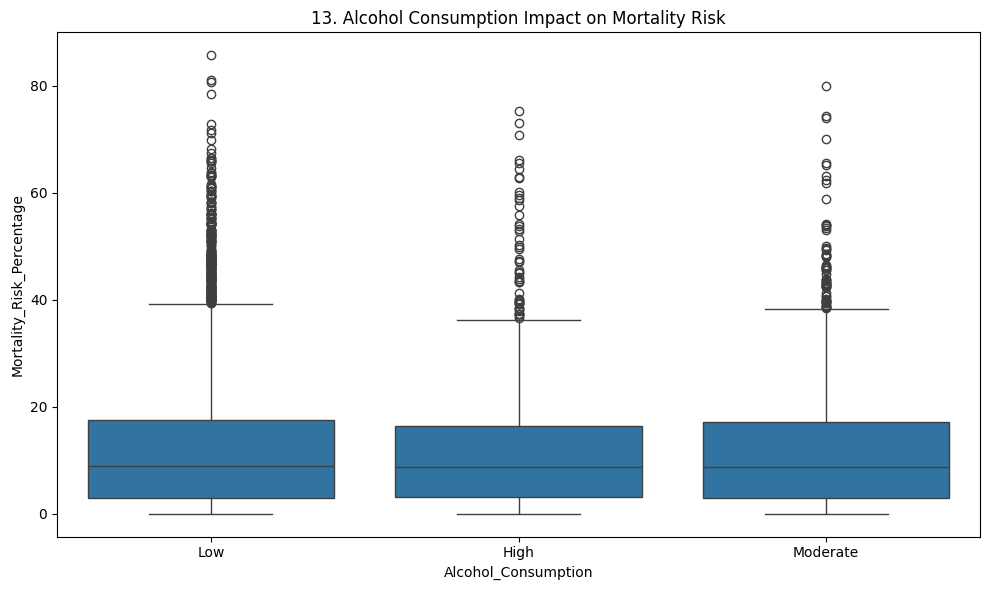

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Alcohol_Consumption', y='Mortality_Risk_Percentage')
plt.title(f'{plot_no}. Alcohol Consumption Impact on Mortality Risk')
show_fig()
plot_no += 1

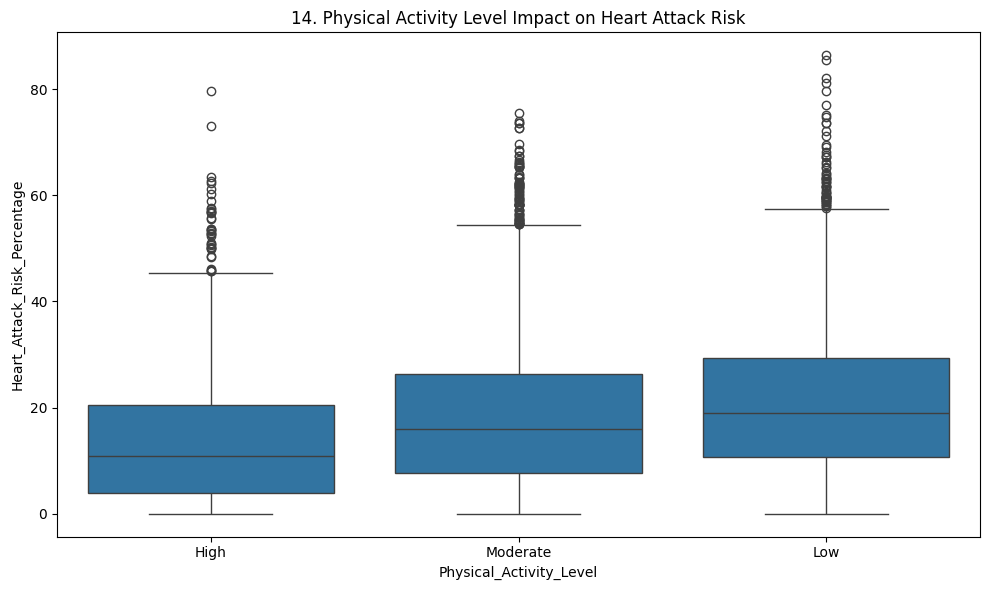

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Physical_Activity_Level', y='Heart_Attack_Risk_Percentage')
plt.title(f'{plot_no}. Physical Activity Level Impact on Heart Attack Risk')
show_fig()
plot_no += 1

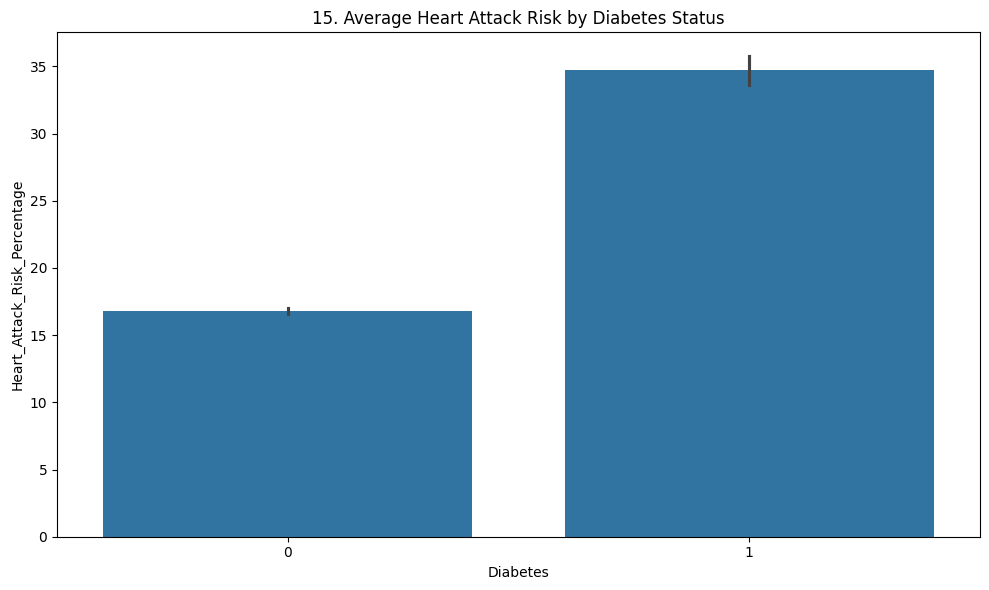

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Diabetes', y='Heart_Attack_Risk_Percentage')
plt.title(f'{plot_no}. Average Heart Attack Risk by Diabetes Status')
show_fig()
plot_no += 1

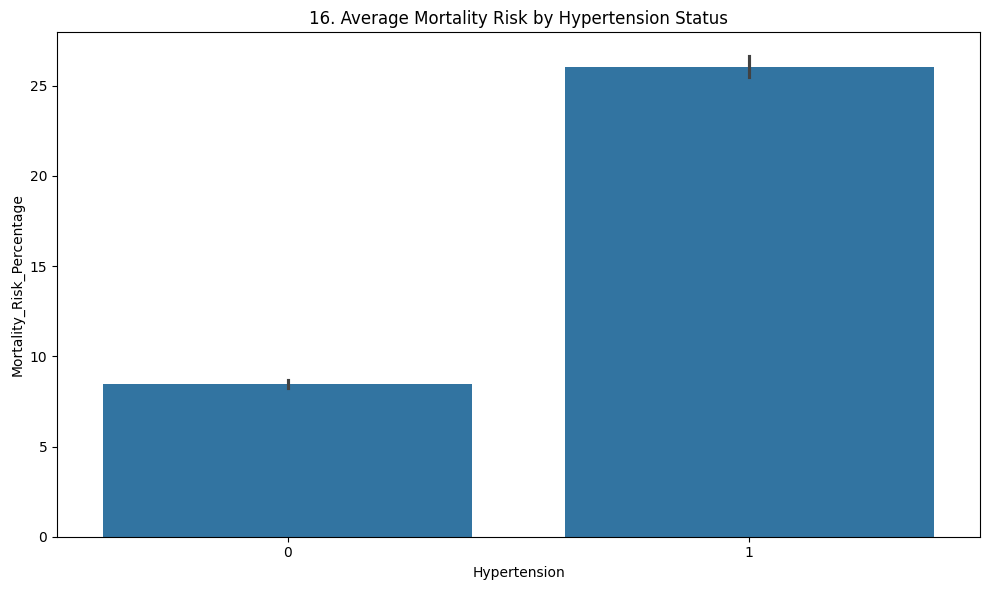

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Hypertension', y='Mortality_Risk_Percentage')
plt.title(f'{plot_no}. Average Mortality Risk by Hypertension Status')
show_fig()
plot_no += 1

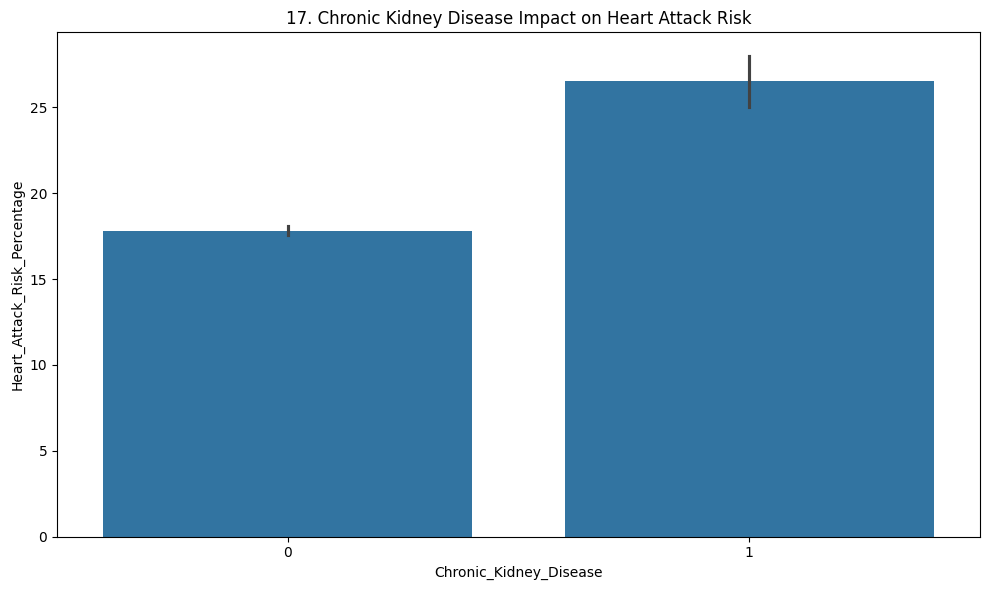

In [32]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Chronic_Kidney_Disease', y='Heart_Attack_Risk_Percentage')
plt.title(f'{plot_no}. Chronic Kidney Disease Impact on Heart Attack Risk')
show_fig()
plot_no += 1

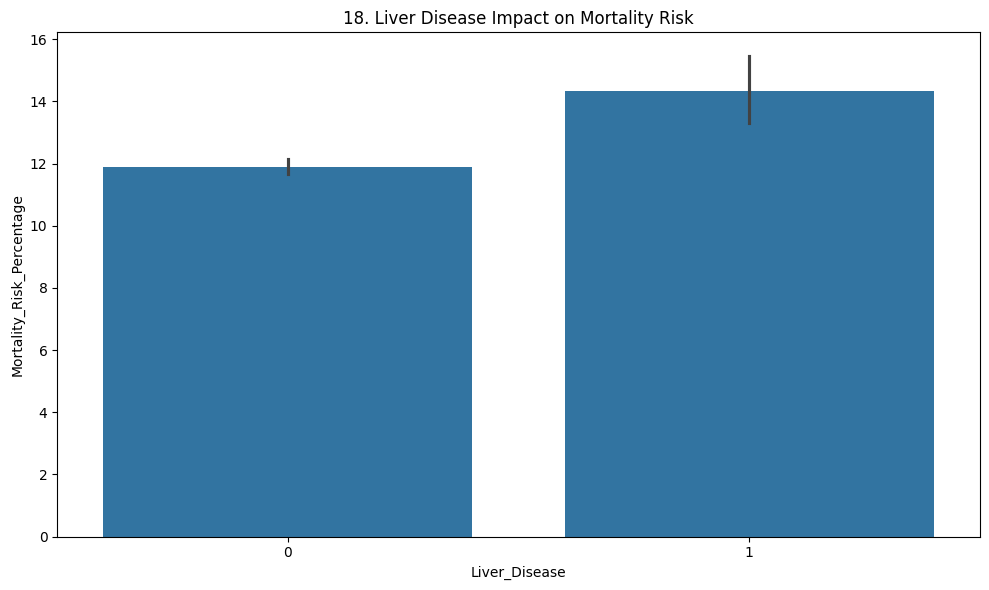

In [33]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Liver_Disease', y='Mortality_Risk_Percentage')
plt.title(f'{plot_no}. Liver Disease Impact on Mortality Risk')
show_fig()
plot_no += 1

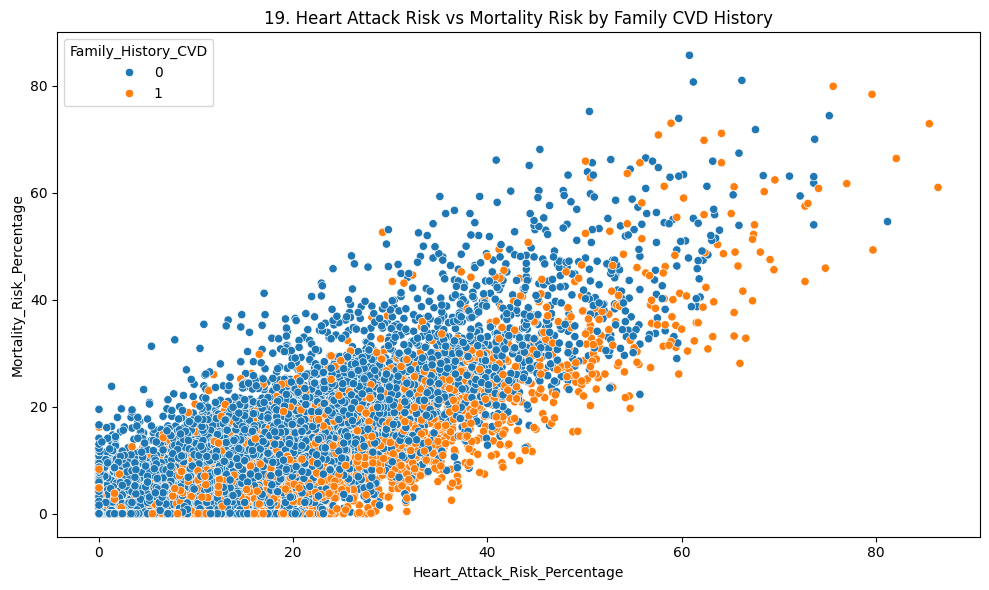

In [34]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Heart_Attack_Risk_Percentage', y='Mortality_Risk_Percentage', hue='Family_History_CVD')
plt.title(f'{plot_no}. Heart Attack Risk vs Mortality Risk by Family CVD History')
show_fig()
plot_no += 1

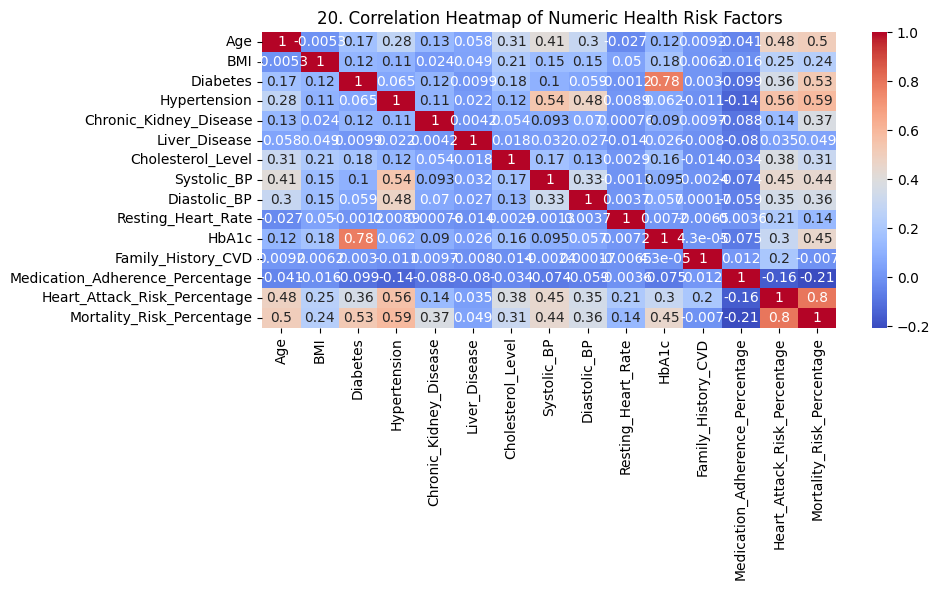

In [35]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Health Risk Factors')
show_fig()
plot_no += 1

# Model Training

## Drop patient id because it is not useful for training

In [36]:
df = df.drop(columns=['Patient_ID'], errors='ignore')

## Convert categorical columns into numbers

In [37]:
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

## Create binary target from heart attack risk percentage

In [38]:
df['Heart_Attack_Risk_Class'] = (df['Heart_Attack_Risk_Percentage'] >= df['Heart_Attack_Risk_Percentage'].median()).astype(int)

## Split features and target

In [39]:
X = df.drop(columns=['Heart_Attack_Risk_Percentage', 'Heart_Attack_Risk_Class'])
y = df['Heart_Attack_Risk_Class']

## Split data into training and testing parts

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Scale feature values for logistic regression

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Create logistic regression model

In [42]:
model = LogisticRegression(max_iter=1000)

## Train model

In [43]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## Predict test data

In [44]:
y_pred = model.predict(X_test_scaled)

## Calculate accuracy score

In [45]:
accuracy = accuracy_score(y_test, y_pred)

## Print model accuracy

In [46]:
print(f"Model Accuracy: {round(accuracy * 100)}%")

Model Accuracy: 88%


## Print classification report

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       997
           1       0.90      0.86      0.88      1003

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



## Create confusion matrix

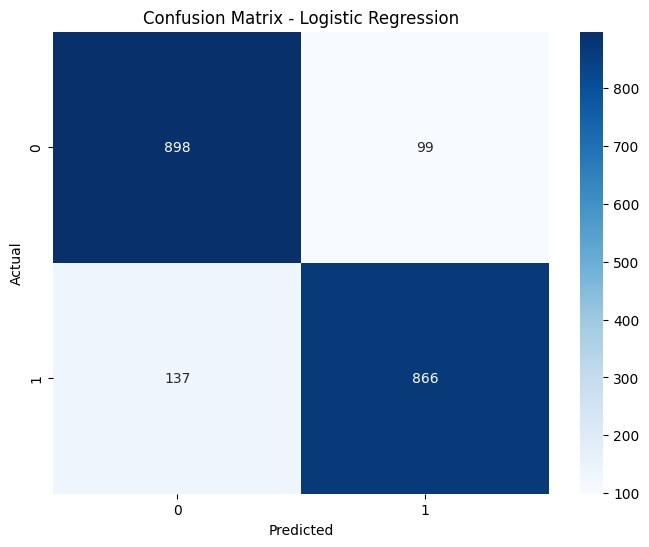

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()